In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
class BacktestCrossMA:
    def __init__(self) -> None:
        self.df = pd.DataFrame()

    def load_data(self, path):
        self.df = pd.read_csv(path)
        self.df["date"] = pd.to_datetime(self.df["date"], unit="ms")
        self.df = self.df.set_index(self.df["date"])
        del self.df["date"]

    def populate_indicators(self):
        self.df['ma50'] = self.df['close'].rolling(50).mean()
        self.df['ma200'] = self.df['close'].rolling(200).mean()

    def populate_signals(self):
        self.df['buy_signal'] = False
        self.df['sell_signal'] = False
        self.df.loc[(self.df['ma50'] > self.df['ma200']), 'buy_signal'] = True
        self.df.loc[(self.df['ma50'] < self.df['ma200']), 'sell_signal'] = True

    def run_backtest(self):
        balance = 1000
        position = None
        asset = "BTC"
        fees=0.001

        for index, row in self.df.iterrows():

            if position is None and row['buy_signal']:
                open_price = row['close']
                position = {
                    'open_price': open_price,
                    'usd_size': balance,
                }
                print(f"{index} - Buy for {balance}$ of {asset} at {open_price}$")

            elif position and row['sell_signal']:
                close_price = row['close']
                trade_result = (close_price - position['open_price']) / position['open_price']
                balance = balance + trade_result * position['usd_size']
                position = None
                print(f"{index} - Sell for {balance}$ of {asset} at {close_price}$")
                
            
        
        print(f"Final balance: {balance}$")

bt = BacktestCrossMA()
bt.load_data('BTC-USDT.csv')
bt.populate_indicators()
bt.populate_signals()
bt.run_backtest()


2017-08-25 11:00:00 - Buy for 1000$ of BTC at 4361.27$
2017-09-04 06:00:00 - Sell for 1022.5851644131182$ of BTC at 4459.77$
2017-09-07 21:00:00 - Buy for 1022.5851644131182$ of BTC at 4641.13$
2017-09-09 13:00:00 - Sell for 947.4588776015138$ of BTC at 4300.16$
2017-09-19 09:00:00 - Buy for 947.4588776015138$ of BTC at 3940.2$
2017-09-22 21:00:00 - Sell for 871.4760516705198$ of BTC at 3624.21$
2017-09-26 13:00:00 - Buy for 871.4760516705198$ of BTC at 3928.33$
2017-10-05 07:00:00 - Sell for 921.5617492024618$ of BTC at 4154.1$
2017-10-06 17:00:00 - Buy for 921.5617492024618$ of BTC at 4336.16$
2017-10-19 19:00:00 - Sell for 1192.0777488092249$ of BTC at 5609.0$
2017-10-20 15:00:00 - Buy for 1192.0777488092249$ of BTC at 5889.99$
2017-10-25 02:00:00 - Sell for 1072.4670145348434$ of BTC at 5299.0$
2017-10-27 21:00:00 - Buy for 1072.4670145348434$ of BTC at 5769.6$
2017-10-28 17:00:00 - Sell for 1059.5983769488328$ of BTC at 5700.37$
2017-10-29 21:00:00 - Buy for 1059.5983769488328$ of

Nombre de signaux d'achat: 26744
Nombre de signaux de vente: 24466


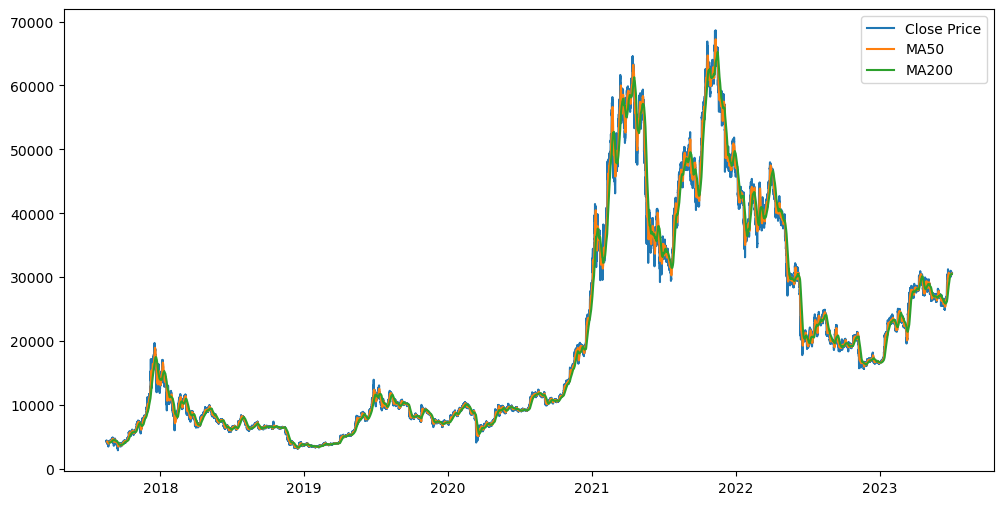

2017-08-25 11:00:00 - Buy for 1000$ of BTC at 4361.27$
2017-09-04 06:00:00 - Sell for 1022.5851644131182$ of BTC at 4459.77$
2017-09-07 21:00:00 - Buy for 1022.5851644131182$ of BTC at 4641.13$
2017-09-09 13:00:00 - Sell for 947.4588776015138$ of BTC at 4300.16$
2017-09-19 09:00:00 - Buy for 947.4588776015138$ of BTC at 3940.2$
2017-09-22 21:00:00 - Sell for 871.4760516705198$ of BTC at 3624.21$
2017-09-26 13:00:00 - Buy for 871.4760516705198$ of BTC at 3928.33$
2017-10-05 07:00:00 - Sell for 921.5617492024618$ of BTC at 4154.1$
2017-10-06 17:00:00 - Buy for 921.5617492024618$ of BTC at 4336.16$
2017-10-19 19:00:00 - Sell for 1192.0777488092249$ of BTC at 5609.0$
2017-10-20 15:00:00 - Buy for 1192.0777488092249$ of BTC at 5889.99$
2017-10-25 02:00:00 - Sell for 1072.4670145348434$ of BTC at 5299.0$
2017-10-27 21:00:00 - Buy for 1072.4670145348434$ of BTC at 5769.6$
2017-10-28 17:00:00 - Sell for 1059.5983769488328$ of BTC at 5700.37$
2017-10-29 21:00:00 - Buy for 1059.5983769488328$ of

In [76]:
class BacktestCrossMA:
    def __init__(self) -> None:
        self.df = pd.DataFrame()
        self.trades=[]
        self.days=[]
        self.final_balance = 0 

    def load_data(self, path):
        self.df = pd.read_csv(path)
        self.df["date"] = pd.to_datetime(self.df["date"], unit="ms")
        self.df = self.df.set_index(self.df["date"])
        del self.df["date"]

    def populate_indicators(self):
        self.df['ma50'] = self.df['close'].rolling(50).mean()
        self.df['ma200'] = self.df['close'].rolling(200).mean()
       
    def populate_signals(self):
        self.df['buy_signal'] = False
        self.df['sell_signal'] = False
        self.df.loc[(self.df['ma50'] > self.df['ma200']), 'buy_signal'] = True
        self.df.loc[(self.df['ma50'] < self.df['ma200']), 'sell_signal'] = True
        # Ajout de débogage pour vérifier les signaux
        print(f"Nombre de signaux d'achat: {self.df['buy_signal'].sum()}")
        print(f"Nombre de signaux de vente: {self.df['sell_signal'].sum()}")


    def run_backtest(self):
        balance = 1000
        position = None
        asset = "BTC"
        fees=0.001

        for index, row in self.df.iterrows():

            if position is None and row['buy_signal']:
                open_price = row['close']
                position = {
                    'open_price': open_price,
                    'usd_size': balance,
                }
                self.trades.append({
                    'buy_date': index,
                    'buy_price': open_price,
                    'usd_size': balance,
                    'open_reason': 'MA Cross Up'
                })
                print(f"{index} - Buy for {balance}$ of {asset} at {open_price}$")

            elif position and row['sell_signal']:
                close_price = row['close']
                trade_result = (close_price - position['open_price']) / position['open_price']
                profit = trade_result * position['usd_size']
                balance = balance + profit
                if len(self.trades) > 0:
                    self.trades[-1]['sell_date'] = index
                    self.trades[-1]['sell_price'] = close_price
                    self.trades[-1]['profit'] = profit 
                    self.trades[-1]['close_reason'] = 'MA Cross Down'
                position = None
                print(f"{index} - Sell for {balance}$ of {asset} at {close_price}$")
                
            self.days.append({
                'date':index,
                'balance':balance,
                'price':row['close']
            })   
        self.final_balance = balance
        
    def backtest_analysis(self):
        self.df_trades = pd.DataFrame(self.trades)
        self.df_days = pd.DataFrame(self.days)

        if self.df_trades.empty:
            raise Exception("No trades found")
        if self.df_days.empty:
            raise Exception("No days found")
    #calcul des retours et resultats des trades
        self.df_days['evolution'] = self.df_days['balance'].diff()
        self.df_days['daily_return'] = self.df_days['evolution']/self.df_days['balance'].shift(1)

        self.df_trades["trade_result"] = self.df_trades["profit"]
        self.df_trades["trade_result_pct"] = (self.df_trades["profit"] / self.df_trades["usd_size"])
        self.df_trades["trades_duration"] = self.df_trades["sell_date"] - self.df_trades["buy_date"]
        print("Trades DataFrame:")
        print(self.df_trades)
        print("\nDays DataFrame:")
        print(self.df_days)
    #analyse des drawdan et performance
    
        self.df_days["balance_ath"] = self.df_days["balance"].cummax()
        self.df_days["drawdown"] = self.df_days["balance_ath"] - self.df_days["balance"]
        self.df_days["drawdown_pct"] = self.df_days["drawdown"] / self.df_days["balance_ath"]
        
        
        total_trades = len(self.df_trades)
        total_days = len(self.df_days)
        print(total_trades)
        mean_trades_per_days = total_trades / total_days
        mean_trades_duration = self.df_trades['trades_duration'].mean()
        
        good_trades = self.df_trades.loc[self.df_trades["trade_result"] > 0]
        total_good_trades = len(good_trades)
        avg_profit_good_trades = good_trades["trade_result_pct"].mean()
        mean_good_trades_duration = good_trades["trades_duration"].mean()
        global_win_rate = total_good_trades / total_trades
        
        
        bad_trades = self.df_trades.loc[self.df_trades["trade_result"] < 0]
        total_bad_trades = len(bad_trades)
        avg_profit_bad_trades = bad_trades["trade_result_pct"].mean()
        mean_bad_trades_duration = bad_trades["trades_duration"].mean()
        
        avg_profit = (avg_profit_good_trades * total_good_trades + avg_profit_bad_trades * total_bad_trades) / total_trades

        
        best_trade = self.df_trades.loc[self.df_trades["trade_result_pct"].idxmax()]
        worst_trade = self.df_trades.loc[self.df_trades["trade_result_pct"].idxmin()]
        sharpe_ratio = (365**(0.5) * self.df_days['daily_return'].mean())/self.df_days['daily_return'].std()


        
        
        
        
        print(f"Period: [{self.df_days.iloc[0]['date']}] -> [{self.df_days.iloc[-1]['date']}]")
        print(f"Initial balance: {round(1000,2)} $")

        print("\n--- General Information ---")
        print(f"Final balance: {round(self.final_balance,2)} $")
        print(f"Performance: {round(self.final_balance/1000*100-100,2)} %") 
        print(f"Worst Drawdown: -{round(self.df_days['drawdown_pct'].max()*100, 2)}%")
        print(f"Total trades on the period: {total_trades}")
        print(f"Average Profit: {round(avg_profit*100, 2)} %")
        print(f"Global Win rate: {round(global_win_rate*100, 2)} %")

        print("\n--- Trades Information ---")
        print(f"Mean Trades per day: {round(mean_trades_per_days, 2)}")
        print(f"Mean Trades Duration: {mean_trades_duration}")
        print(f"Best trades: +{round(best_trade['trade_result_pct']*100, 2)} % the {best_trade['buy_date']} -> {best_trade['sell_date']}")
        print(f"Worst trades: {round(worst_trade['trade_result_pct']*100, 2)} % the {worst_trade['buy_date']} -> {worst_trade['sell_date']}")
        print(f"Total Good trades on the period: {total_good_trades}")
        print(f"Total Bad trades on the period: {total_bad_trades}")
        print(f"Average Good Trades result: {round(avg_profit_good_trades*100, 2)} %")
        print(f"Average Bad Trades result: {round(avg_profit_bad_trades*100, 2)} %")
        print(f"Mean Good Trades Duration: {mean_good_trades_duration}")
        print(f"Mean Bad Trades Duration: {mean_bad_trades_duration}")

        print("\n--- Trades reasons ---")
        print(self.df_trades["open_reason"].value_counts().to_string())
        print(self.df_trades["close_reason"].value_counts().to_string())
        print(f"Sharpe Ratio: {round(sharpe_ratio,2)}")
        

bt = BacktestCrossMA()
bt.load_data('BTC-USDT.csv')
bt.populate_indicators()
bt.populate_signals()
plt.figure(figsize=(12, 6))
plt.plot(bt.df.index, bt.df['close'], label='Close Price')
plt.plot(bt.df.index, bt.df['ma50'], label='MA50')
plt.plot(bt.df.index, bt.df['ma200'], label='MA200')
plt.legend()
plt.show()

bt.run_backtest()
bt.backtest_analysis()